# 6-Class Defect Detection — MobileNetV2

This notebook trains a **single MobileNetV2** model to classify images into **6 defect classes** simultaneously:

| Class | Label index |
|-------|-------------|
| Cracking | 0 |
| No_Cracking | 1 |
| No_Stringing | 2 |
| No_Warping | 3 |
| Stringing | 4 |
| Warping | 5 |

**Architecture:** MobileNetV2 (ImageNet weights, frozen base) + custom head → `Dense(6, softmax)`  
**Loss:** `categorical_crossentropy`  
**Split:** 80% train / 10% val / 10% test  
**Data location:** `data/` folder with 6 sub-folders (one per class)

---
## 1. Imports & Configuration

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.applications import MobileNetV2

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
)

# Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# Config
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
EPOCHS     = 50
LR         = 1e-4
NUM_CLASSES = 6

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

2026-05-11 07:15:46.661372: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778480146.765756    3230 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778480146.794308    3230 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-11 07:15:47.030880: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.18.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## 2. Load & Split the Dataset

All 6 class folders live under `data/`.  
We collect every `.jpg`, assign integer labels, then split **80 / 10 / 10**.

In [3]:
DATA_DIR = os.path.join(os.getcwd(), "data")

# Class names are the sorted sub-folder names → deterministic label assignment
CLASS_NAMES = sorted(os.listdir(DATA_DIR))
print(f"Classes ({len(CLASS_NAMES)}): {CLASS_NAMES}")

# Collect paths + integer labels
all_paths, all_labels = [], []
for label_idx, class_name in enumerate(CLASS_NAMES):
    folder = os.path.join(DATA_DIR, class_name)
    images = [os.path.join(folder, f) for f in os.listdir(folder) if f.endswith(".jpg")]
    all_paths.extend(images)
    all_labels.extend([label_idx] * len(images))
    print(f"  {class_name:15s}: {len(images)} images  (label={label_idx})")

print(f"\nTotal: {len(all_paths)} images")

# Shuffle before splitting (fixed seed)
rng = np.random.default_rng(SEED)
idx = rng.permutation(len(all_paths))
all_paths  = np.array(all_paths)[idx]
all_labels = np.array(all_labels)[idx]

# 80 / 10 / 10 split
n       = len(all_paths)
n_train = int(n * 0.80)
n_val   = int(n * 0.10)

train_paths, train_labels = all_paths[:n_train],          all_labels[:n_train]
val_paths,   val_labels   = all_paths[n_train:n_train+n_val], all_labels[n_train:n_train+n_val]
test_paths,  test_labels  = all_paths[n_train+n_val:],    all_labels[n_train+n_val:]

print(f"\nTrain : {len(train_paths)}")
print(f"Val   : {len(val_paths)}")
print(f"Test  : {len(test_paths)}")

Classes (6): ['Cracking', 'No_Cracking', 'No_Stringing', 'No_Warping', 'Stringing', 'Warping']
  Cracking       : 1663 images  (label=0)
  No_Cracking    : 2042 images  (label=1)
  No_Stringing   : 1811 images  (label=2)
  No_Warping     : 1815 images  (label=3)
  Stringing      : 2555 images  (label=4)
  Warping        : 1707 images  (label=5)

Total: 11593 images

Train : 9274
Val   : 1159
Test  : 1160


---
## 3. Build tf.data Pipelines

Preprocessing (identical to binary models):
- Resize to **224 × 224**
- Normalize to **[0, 1]**
- Labels are **one-hot encoded** (required for `categorical_crossentropy`)

Augmentation applied **only to training set**: random flip, rotation ±20°, brightness ±20%.

In [5]:
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    label = tf.one_hot(label, NUM_CLASSES)   # one-hot for categorical_crossentropy
    return img, label

_random_rotation = tf.keras.layers.RandomRotation(0.056)
def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.2)
    img = tf.clip_by_value(img, 0.0, 1.0)
    img = _random_rotation(img, training=True)   # reuse the same layer instance
    return img, label

train_ds = (
    tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    .map(augment, num_parallel_calls=AUTOTUNE)
    .shuffle(1000, seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print("✅ Datasets ready.")

✅ Datasets ready.


---
## 4. Build the Model

Same MobileNetV2 architecture as the binary models, with **one change**:  
the output head uses `Dense(6, softmax)` instead of `Dense(1, sigmoid)`.

The MobileNetV2 base is **fully frozen** in this Phase-1 training.

In [6]:
# ── Base model (frozen) ───────────────────────────────────────────────────────
base_model = MobileNetV2(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights="imagenet",
)
base_model.trainable = False   # freeze all base layers

print(f"Base model layers  : {len(base_model.layers)}")
print(f"Trainable weights  : {len(base_model.trainable_weights)}")

# ── Custom head ──────────────────────────────────────────────────────────────
inputs = keras.Input(shape=(*IMG_SIZE, 3), name="input_image")
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
x = layers.Dense(256, activation="relu", name="dense_256")(x)
x = layers.Dropout(0.3, name="dropout_03")(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax", name="output")(x)  # 6-class softmax

model = keras.Model(inputs, outputs, name="MobileNetV2_6Class")
model.summary()

Base model layers  : 154
Trainable weights  : 0


Model: "MobileNetV2_6Class"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_03 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,462 (9.87 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

---
## 5. Compile

- **Loss:** `categorical_crossentropy` (multi-class, one-hot labels)
- **Optimizer:** Adam, lr = 1e-4
- **Metric:** accuracy

In [7]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
print("✅ Model compiled.")

✅ Model compiled.


---
## 6. Callbacks

In [8]:
BEST_MODEL_PATH = "best_mobilenetv2_6class.h5"

cb = [
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1,
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1,
    ),
    callbacks.ModelCheckpoint(
        filepath=BEST_MODEL_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
]
print("✅ Callbacks ready.")

✅ Callbacks ready.


---
## 7. Train — Phase 1 (Frozen Base)

In [9]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=cb,
)
print("\n✅ Training complete.")

Epoch 1/50


I0000 00:00:1778480453.800855    3423 service.cc:148] XLA service 0x7ece74111250 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778480453.801272    3423 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 2060 SUPER, Compute Capability 7.5
2026-05-11 07:20:53.978116: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778480454.674868    3423 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/290 ━━━━━━━━━━━━━━━━━━━━ 1:25:52 18s/step - accuracy: 0.0938 - loss: 2.4963

I0000 00:00:1778480459.123075    3423 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


288/290 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.5508 - loss: 1.0626
Epoch 1: val_loss improved from None to 0.49643, saving model to best_mobilenetv2_6class.h5


...

2026-05-11 08:28:23.947032: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:5: Filling up shuffle buffer (this may take a while): 896 of 1000
2026-05-11 08:28:18.500985: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.9383 - loss: 0.1463
Epoch 45: val_loss did not improve from 0.14591
290/290 ━━━━━━━━━━━━━━━━━━━━ 90s 282ms/step - accuracy: 0.9400 - loss: 0.1466 - val_accuracy: 0.9154 - val_loss: 0.1703 - learning_rate: 1.0000e-04
Epoch 46/50
289/290 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.9418 - loss: 0.1458
Epoch 46: val_loss improved from 0.14591 to 0.14043, saving model to best_mobilenetv2_6class.h5



Epoch 46: finished saving model to best_mobilenetv2_6class.h5
290/290 ━━━━━━━━━━━━━━━━━━━━ 74s 225ms/step - accuracy: 0.9420 - loss: 0.1426 - val_accuracy: 0.9405 - val_loss: 0.1404 - learning_rate: 1.0000e-04
Epoch 47/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.9409 - loss: 0.1398
Epoch 47: val_loss improved from 0.14043 to 0.13962, saving model to best_mobilenetv2_6class.h5



Epoch 47: finished saving model to best_mobilenetv2_6class.h5
290/290 ━━━━━━━━━━━━━━━━━━━━ 88s 276ms/step - accuracy: 0.9413 - loss: 0.1407 - val_accuracy: 0.9431 - val_loss: 0.1396 - learning_rate: 1.0000e-04
Epoch 48/50
289/290 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 0.9430 - loss: 0.1389
Epoch 48: val_loss improved from 0.13962 to 0.13577, saving model to best_mobilenetv2_6class.h5



Epoch 48: finished saving model to best_mobilenetv2_6class.h5
290/290 ━━━━━━━━━━━━━━━━━━━━ 80s 250ms/step - accuracy: 0.9420 - loss: 0.1398 - val_accuracy: 0.9405 - val_loss: 0.1358 - learning_rate: 1.0000e-04
Epoch 49/50
288/290 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 0.9460 - loss: 0.1376
Epoch 49: val_loss did not improve from 0.13577
290/290 ━━━━━━━━━━━━━━━━━━━━ 80s 247ms/step - accuracy: 0.9444 - loss: 0.1411 - val_accuracy: 0.9241 - val_loss: 0.1593 - learning_rate: 1.0000e-04
Epoch 50/50
289/290 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.9499 - loss: 0.1307
Epoch 50: val_loss did not improve from 0.13577
290/290 ━━━━━━━━━━━━━━━━━━━━ 80s 246ms/step - accuracy: 0.9459 - loss: 0.1370 - val_accuracy: 0.9413 - val_loss: 0.1368 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 48.

✅ Training complete.


---
## 8. Training History

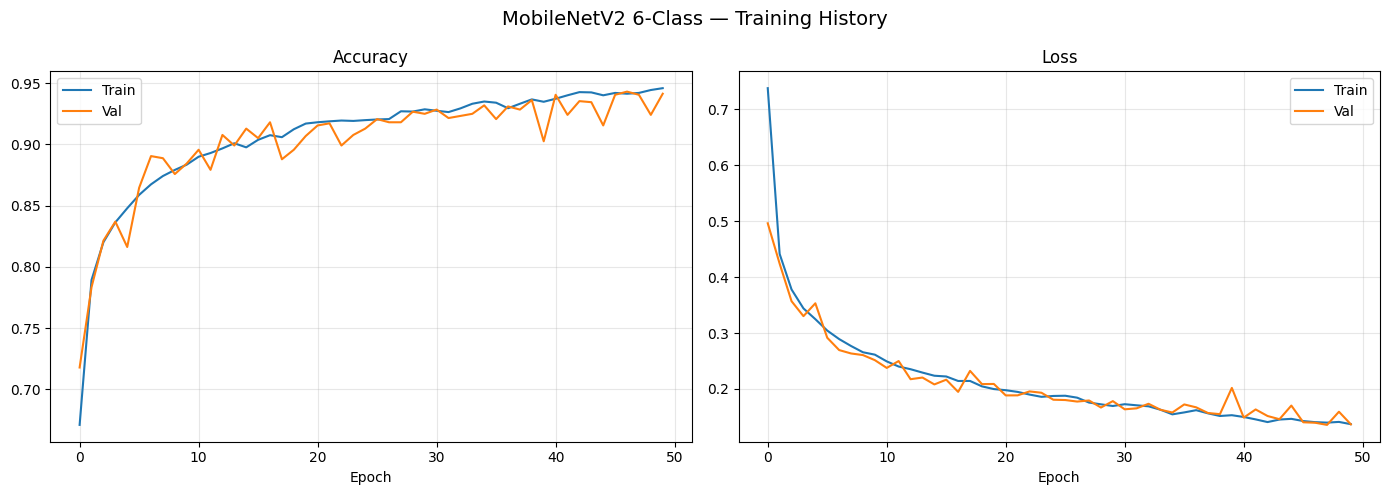

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["accuracy"],     label="Train")
axes[0].plot(history.history["val_accuracy"],  label="Val")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history["loss"],     label="Train")
axes[1].plot(history.history["val_loss"],  label="Val")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("MobileNetV2 6-Class — Training History", fontsize=14)
plt.tight_layout()
plt.show()

---
## 9. Evaluate on Test Set

In [11]:
best_model = keras.models.load_model(BEST_MODEL_PATH)

y_pred_probs = best_model.predict(test_ds, verbose=1)  # shape (N, 6)
y_pred = np.argmax(y_pred_probs, axis=1)               # predicted class index
y_true = test_labels                                   # integer ground-truth labels

acc = accuracy_score(y_true, y_pred)
print(f"\nTest Accuracy: {acc:.4f}  ({acc*100:.2f}%)\n")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

37/37 ━━━━━━━━━━━━━━━━━━━━ 15s 289ms/step

Test Accuracy: 0.9422  (94.22%)

              precision    recall  f1-score   support

    Cracking       1.00      0.97      0.99       174
 No_Cracking       0.98      1.00      0.99       212
No_Stringing       0.93      0.86      0.89       162
  No_Warping       0.89      0.97      0.93       185
   Stringing       0.92      0.96      0.94       262
     Warping       0.96      0.86      0.91       165

    accuracy                           0.94      1160
   macro avg       0.95      0.94      0.94      1160
weighted avg       0.94      0.94      0.94      1160



---
## 10. Confusion Matrix

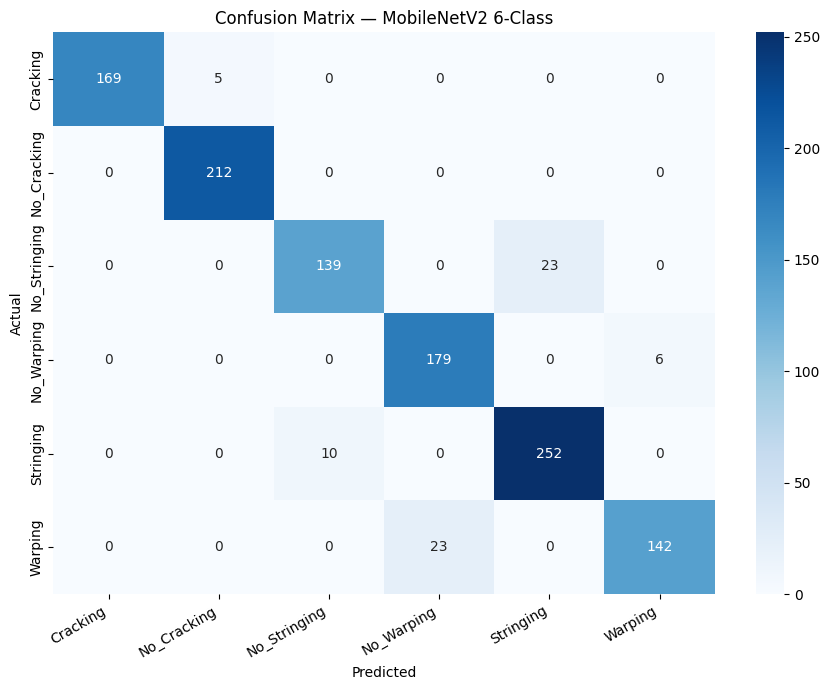

In [12]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — MobileNetV2 6-Class")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

---
## 11. Save the Model

In [13]:
best_model.save("mobilenetv2_6class_final.h5")
best_model.save("mobilenetv2_6class_savedmodel")
print("✅ mobilenetv2_6class_final.h5")
print("✅ mobilenetv2_6class_savedmodel/")

ValueError: Invalid filepath extension for saving. Please add either a `.keras` extension for the native Keras format (recommended) or a `.h5` extension. Use `model.export(filepath)` if you want to export a SavedModel for use with TFLite/TFServing/etc. Received: filepath=mobilenetv2_6class_savedmodel.